# Infra-FM: Multi-Continent Classification

Evaluates the multi-continent pretrained encoder on asset classification
across all available regions combined.

**Experiments:**
1. SimCLR pretrained (200ep, temp=0.1) — linear probe (frozen encoder)
2. SimCLR pretrained (200ep, temp=0.1) — fine-tuned (unfrozen encoder)

**Dataset:** Combined central-america + australia-oceania + africa + south-america

**Note on bands:** Central america tiles have 10 bands (S2+SAR+TIR), other
regions have 9 bands (S2+SAR). We use bands 0-8 (9 bands) across all regions,
dropping landsat_thermal from central america for consistency.

**Before running:**
- Runtime → Change runtime type → GPU (T4)
- `My Drive/infra_fm/results/pretrain_multicontinent/best.pt` exists
- All 4 regional datasets in `My Drive/infra_fm/datasets/`

## 1. Mount Drive + check GPU

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import torch
print(f'GPU available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU. Runtime -> Change runtime type -> GPU.')

Mounted at /content/drive
GPU available: True
GPU: Tesla T4
Memory: 15.6 GB


## 2. Install + extract code

In [2]:
%%capture
!pip install scipy opencv-python-headless scikit-learn

In [3]:
import os, sys, zipfile, json
from pathlib import Path

DRIVE_ROOT = '/content/drive/MyDrive/infra_fm'
CODE_ZIP   = f'{DRIVE_ROOT}/code/infra_fm_curation.zip'
EXTRACT_TO = '/content/infra_fm_clean'
CODE_ROOT  = f'{EXTRACT_TO}/infra_fm_code_only'

if not Path(f'{CODE_ROOT}/downstream').exists():
    print('Extracting code...')
    os.makedirs(EXTRACT_TO, exist_ok=True)
    with zipfile.ZipFile(CODE_ZIP, 'r') as z:
        for member in z.namelist():
            clean_path = member.replace('\\', '/')
            target = os.path.join(EXTRACT_TO, clean_path)
            if clean_path.endswith('/'):
                os.makedirs(target, exist_ok=True)
            else:
                os.makedirs(os.path.dirname(target), exist_ok=True)
                with z.open(member) as src, open(target, 'wb') as dst:
                    dst.write(src.read())
    print('Done.')
else:
    print('Already extracted.')

sys.path.insert(0, CODE_ROOT)
os.chdir(CODE_ROOT)

from downstream.common.models import EncoderBackbone, SimCLRModel, LinearClassifier
from downstream.common.transforms import build_eval_transform
from downstream.common.utils import choose_device, ensure_dir, save_checkpoint, save_json, set_seed
from downstream.asset_classification.datasets import AssetClassificationDataset
print('Imports OK')

Extracting code...
Done.
Imports OK


## 3. Configuration

In [4]:
DATASETS_DIR = f'{DRIVE_ROOT}/datasets'
CHECKPOINT   = f'{DRIVE_ROOT}/results/pretrain_multicontinent/best.pt'
RESULTS_DIR  = f'{DRIVE_ROOT}/results/classification_multicontinent'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Regions to combine — all must have consistent band count
REGIONS = [
    'central-america',
    'australia-oceania',
    'africa',
    'south-america',
]

# 9 bands (S2 + SAR) — drops landsat_thermal from central america
# for consistency across all regions
BAND_INDICES   = '0,1,2,3,4,5,6,7,8'
BACKBONE       = 'resnet18'
EPOCHS         = 30
BATCH_SIZE     = 64
LR_PROBE       = 1e-2   # higher LR for linear probe
LR_FINETUNE    = 1e-3
WEIGHT_DECAY   = 1e-4
TRAIN_FRACTION = 0.8
SEED           = 42
TAIL_EPOCHS    = 5
IMAGE_SIZE     = 224

# Verify checkpoint
ckpt = torch.load(CHECKPOINT, map_location='cpu')
print('Checkpoint loaded:')
print(f'  Epoch:       {ckpt["epoch"]}')
print(f'  Best loss:   {ckpt["loss"]:.4f}')
print(f'  in_channels: {ckpt["in_channels"]}')
print(f'  band_indices:{ckpt["band_indices"]}')
print(f'  Keys:        {len(ckpt["model_state_dict"])}')

# Verify datasets
print('\nDataset availability:')
total_tiles = 0
available = []
for region in REGIONS:
    manifest_path = Path(f'{DATASETS_DIR}/dataset_{region}_stac_v1/manifest.json')
    if manifest_path.exists():
        m = json.load(open(manifest_path))
        n = m['n_tiles']
        shape = m['records'][0].get('image_shape', [])
        print(f'  {region:25s} {n:>6,} tiles | shape={shape}')
        total_tiles += n
        available.append(region)
    else:
        print(f'  {region:25s} NOT FOUND')
print(f'\nTotal tiles: {total_tiles:,}')

Checkpoint loaded:
  Epoch:       194
  Best loss:   0.0243
  in_channels: 9
  band_indices:0,1,2,3,4,5,6,7,8
  Keys:        124

Dataset availability:
  central-america            1,782 tiles | shape=[10, 61, 61]
  australia-oceania          3,257 tiles | shape=[9, 60, 60]
  africa                     5,869 tiles | shape=[9, 60, 60]
  south-america             11,313 tiles | shape=[9, 61, 61]

Total tiles: 22,221


## 4. Build combined dataset

In [5]:
import random
import csv
import torch
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, Subset, ConcatDataset
from sklearn.metrics import f1_score


def short_class(c):
    return (
        c.replace('energy.', '')
         .replace('distribution.', 'dx_')
         .replace('transmission.', 'tx_')
    )


# Load all regional datasets with consistent band indices
transform = build_eval_transform(IMAGE_SIZE)
regional_datasets = []
all_classes = set()

for region in available:
    dataset_root = f'{DATASETS_DIR}/dataset_{region}_stac_v1'
    try:
        ds = AssetClassificationDataset(
            dataset_root=dataset_root,
            transform=transform,
            band_indices=BAND_INDICES,
        )
        regional_datasets.append((region, ds))
        all_classes.update(ds.label_space.classes)
        print(f'  {region:25s} {len(ds):>6,} samples | classes: {ds.label_space.classes}')
    except Exception as e:
        print(f'  {region:25s} FAILED: {e}')

# Build unified label space across all regions
from downstream.asset_classification.datasets import LabelSpace
unified_classes = sorted(all_classes)
unified_label_space = LabelSpace(classes=unified_classes)
print(f'\nUnified classes ({len(unified_classes)}): {unified_classes}')

# Re-load with unified label space so all regions use same class indices
unified_datasets = []
for region, _ in regional_datasets:
    dataset_root = f'{DATASETS_DIR}/dataset_{region}_stac_v1'
    ds = AssetClassificationDataset(
        dataset_root=dataset_root,
        transform=transform,
        band_indices=BAND_INDICES,
        label_space=unified_label_space,
    )
    unified_datasets.append(ds)

combined = ConcatDataset(unified_datasets)
print(f'\nCombined dataset: {len(combined):,} tiles')

  central-america            1,782 samples | classes: ['energy.distribution.substation', 'energy.distribution.substation_untyped', 'energy.transmission.substation']
  australia-oceania          3,257 samples | classes: ['energy.distribution.substation', 'energy.distribution.substation_untyped', 'energy.transmission.substation']
  africa                     5,869 samples | classes: ['energy.distribution.substation', 'energy.distribution.substation_untyped', 'energy.transmission.substation']
  south-america             11,313 samples | classes: ['energy.distribution.substation', 'energy.distribution.substation_untyped', 'energy.transmission.substation']

Unified classes (3): ['energy.distribution.substation', 'energy.distribution.substation_untyped', 'energy.transmission.substation']

Combined dataset: 22,221 tiles


## 5. Shared utilities

In [6]:
def split_indices(n, train_fraction, seed):
    idxs = list(range(n))
    random.Random(seed).shuffle(idxs)
    cut = max(1, int(n * train_fraction))
    return idxs[:cut], idxs[cut:]


def compute_class_weights(combined_dataset, train_indices, classes, device):
    counts = [0] * len(classes)
    for idx in train_indices:
        item = combined_dataset[idx]
        counts[item['label'].item()] += 1
    total = sum(counts)
    n_classes = len(counts)
    weights = [total / (n_classes * c) if c > 0 else 0.0 for c in counts]
    print('Class weights:')
    for cls, w, c in zip(classes, weights, counts):
        print(f'  {short_class(cls):35s} count={c:>6}  weight={w:.3f}')
    return torch.tensor(weights, dtype=torch.float32, device=device)


def evaluate(encoder, head, loader, device, classes=None):
    encoder.eval(); head.eval()
    correct, total = 0, 0
    cc = [0] * len(classes) if classes else None
    ct = [0] * len(classes) if classes else None
    with torch.no_grad():
        for batch in loader:
            x = batch['image'].to(device)
            y = batch['label'].to(device)
            pred = head(encoder(x)).argmax(dim=1)
            correct += (pred == y).sum().item()
            total   += y.numel()
            if classes:
                for i in range(len(classes)):
                    mask = (y == i)
                    cc[i] += (pred[mask] == y[mask]).sum().item()
                    ct[i] += mask.sum().item()
    overall = correct / max(total, 1)
    per_class = (
        {cls: round(cc[i] / max(ct[i], 1), 4) for i, cls in enumerate(classes)}
        if classes else None
    )
    return overall, per_class


def run_experiment(name, checkpoint, freeze_encoder, lr,
                   combined_dataset, unified_classes, output_dir):
    print(f'\n{"="*60}')
    print(f'EXPERIMENT: {name}')
    print(f'  freeze_encoder={freeze_encoder}  lr={lr}')
    print('='*60)

    set_seed(SEED)
    out = ensure_dir(output_dir)
    device = choose_device()
    in_channels = len(BAND_INDICES.split(','))

    train_idxs, val_idxs = split_indices(len(combined_dataset), TRAIN_FRACTION, SEED)
    train_loader = DataLoader(Subset(combined_dataset, train_idxs),
                              batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(Subset(combined_dataset, val_idxs),
                              batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)
    print(f'Train: {len(train_idxs):,} | Val: {len(val_idxs):,}')

    # Load encoder
    ckpt = torch.load(checkpoint, map_location='cpu')
    cfg  = ckpt.get('config', {})
    model = SimCLRModel(
        backbone_name=cfg.get('backbone_name', BACKBONE),
        pretrained_backbone=False,
        projection_dim=cfg.get('projection_dim', 128),
        in_channels=in_channels,
    )
    sd = ckpt.get('model_state_dict') or ckpt
    missing, _ = model.load_state_dict(sd, strict=False)
    encoder = model.backbone
    encoder.feature_dim = model.feature_dim
    print(f'Loaded checkpoint: {len(sd)-len(missing)}/{len(sd)} keys matched')

    head = LinearClassifier(encoder.feature_dim, len(unified_classes))
    encoder.to(device); head.to(device)

    if freeze_encoder:
        for p in encoder.parameters():
            p.requires_grad = False
        print('Encoder frozen (linear probe)')

    params    = list(head.parameters()) + [p for p in encoder.parameters()
                                            if p.requires_grad]
    optimizer = AdamW(params, lr=lr, weight_decay=WEIGHT_DECAY)
    weights   = compute_class_weights(combined_dataset, train_idxs,
                                       unified_classes, device)
    criterion = nn.CrossEntropyLoss(weight=weights)

    best_acc    = -1.0
    val_history = []

    with (out / 'metrics.csv').open('w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['epoch', 'train_loss', 'val_acc'])
        writer.writeheader()
        for epoch in range(1, EPOCHS + 1):
            encoder.train(); head.train()
            losses = []
            for batch in train_loader:
                x = batch['image'].to(device, non_blocking=True)
                y = batch['label'].to(device, non_blocking=True)
                optimizer.zero_grad(set_to_none=True)
                loss = criterion(head(encoder(x)), y)
                loss.backward()
                optimizer.step()
                losses.append(loss.item())
            val_acc, _ = evaluate(encoder, head, val_loader, device)
            val_history.append(val_acc)
            train_loss = sum(losses) / max(len(losses), 1)
            writer.writerow({'epoch': epoch,
                             'train_loss': round(train_loss, 6),
                             'val_acc': round(val_acc, 6)})
            f.flush()
            print(f'Epoch {epoch:03d}/{EPOCHS} | '
                  f'loss={train_loss:.4f} | val_acc={val_acc:.4f}')
            if val_acc > best_acc:
                best_acc = val_acc
                save_checkpoint(out / 'checkpoint_best.pt', {
                    'encoder_state': encoder.state_dict(),
                    'head_state':    head.state_dict(),
                    'classes':       unified_classes,
                })

    tail_n    = min(TAIL_EPOCHS, len(val_history))
    tail_vals = val_history[-tail_n:]
    tail_mean = sum(tail_vals) / len(tail_vals)
    tail_std  = (sum((v-tail_mean)**2 for v in tail_vals)/len(tail_vals))**0.5

    _, per_class = evaluate(encoder, head, val_loader, device,
                            classes=unified_classes)

    result = {
        'experiment':    name,
        'best_val_acc':  round(best_acc, 4),
        'tail_mean_acc': round(tail_mean, 4),
        'tail_std_acc':  round(tail_std, 4),
        'tail_epochs':   tail_n,
        'per_class_acc': per_class,
        'classes':       unified_classes,
        'freeze_encoder': freeze_encoder,
        'n_train':       len(train_idxs),
        'n_val':         len(val_idxs),
    }
    save_json(out / 'results_summary.json', result)

    print(f'\nBest val_acc:  {best_acc:.4f}')
    print(f'Tail mean:     {tail_mean:.4f} ± {tail_std:.4f}')
    print('Per-class accuracy:')
    if per_class:
        for cls, acc in per_class.items():
            print(f'  {short_class(cls):35s} {acc:.4f}')

    return result


print('Utilities loaded.')

Utilities loaded.


## 6. Experiment 1 — Linear probe (frozen encoder)

In [7]:
result_probe = run_experiment(
    name             = 'multicontinent_simclr_linear_probe',
    checkpoint       = CHECKPOINT,
    freeze_encoder   = True,
    lr               = LR_PROBE,
    combined_dataset = combined,
    unified_classes  = unified_classes,
    output_dir       = f'{RESULTS_DIR}/linear_probe',
)


EXPERIMENT: multicontinent_simclr_linear_probe
  freeze_encoder=True  lr=0.01
Train: 17,776 | Val: 4,445
Loaded checkpoint: 124/124 keys matched
Encoder frozen (linear probe)


/content/infra_fm_clean/infra_fm_code_only/downstream/common/comm_datasets.py:201: UserWarning: Tile has 10 bands but band_indices=[0, 1, 2, 3, 4, 5, 6, 7, 8] selects only 9. Pass --band-indices explicitly to use all bands (e.g. 0,1,2,3,4,5,6 for sentinel2_ms).
  image = self._load_image(record.path)


Class weights:
  dx_substation                       count=  4214  weight=1.406
  dx_substation_untyped               count= 11006  weight=0.538
  tx_substation                       count=  2556  weight=2.318
Epoch 001/30 | loss=1.1597 | val_acc=0.6135
Epoch 002/30 | loss=1.1115 | val_acc=0.5006
Epoch 003/30 | loss=1.0832 | val_acc=0.6175
Epoch 004/30 | loss=1.1343 | val_acc=0.5501
Epoch 005/30 | loss=1.0456 | val_acc=0.5838
Epoch 006/30 | loss=1.0629 | val_acc=0.5100
Epoch 007/30 | loss=1.0830 | val_acc=0.5811
Epoch 008/30 | loss=1.1106 | val_acc=0.5082
Epoch 009/30 | loss=1.1129 | val_acc=0.4976
Epoch 010/30 | loss=1.0499 | val_acc=0.5163
Epoch 011/30 | loss=1.0766 | val_acc=0.4612
Epoch 012/30 | loss=1.1172 | val_acc=0.6020
Epoch 013/30 | loss=1.1018 | val_acc=0.5190
Epoch 014/30 | loss=1.1175 | val_acc=0.5557
Epoch 015/30 | loss=1.0790 | val_acc=0.4819
Epoch 016/30 | loss=1.0756 | val_acc=0.4846
Epoch 017/30 | loss=1.0869 | val_acc=0.5708
Epoch 018/30 | loss=1.0867 | val_acc=0.542

## 7. Experiment 2 — Fine-tuned (unfrozen encoder)

In [8]:
result_finetuned = run_experiment(
    name             = 'multicontinent_simclr_finetuned',
    checkpoint       = CHECKPOINT,
    freeze_encoder   = False,
    lr               = LR_FINETUNE,
    combined_dataset = combined,
    unified_classes  = unified_classes,
    output_dir       = f'{RESULTS_DIR}/finetuned',
)


EXPERIMENT: multicontinent_simclr_finetuned
  freeze_encoder=False  lr=0.001
Train: 17,776 | Val: 4,445
Loaded checkpoint: 124/124 keys matched
Class weights:
  dx_substation                       count=  4214  weight=1.406
  dx_substation_untyped               count= 11006  weight=0.538
  tx_substation                       count=  2556  weight=2.318
Epoch 001/30 | loss=0.9595 | val_acc=0.4292
Epoch 002/30 | loss=0.8944 | val_acc=0.5678
Epoch 003/30 | loss=0.8568 | val_acc=0.5777
Epoch 004/30 | loss=0.8334 | val_acc=0.5831
Epoch 005/30 | loss=0.8099 | val_acc=0.5318
Epoch 006/30 | loss=0.7845 | val_acc=0.6218
Epoch 007/30 | loss=0.7516 | val_acc=0.6612
Epoch 008/30 | loss=0.7154 | val_acc=0.6324
Epoch 009/30 | loss=0.6709 | val_acc=0.5946
Epoch 010/30 | loss=0.5982 | val_acc=0.4740
Epoch 011/30 | loss=0.5214 | val_acc=0.5438
Epoch 012/30 | loss=0.4384 | val_acc=0.6074
Epoch 013/30 | loss=0.3521 | val_acc=0.6315
Epoch 014/30 | loss=0.2822 | val_acc=0.6130
Epoch 015/30 | loss=0.2154 | 

## 8. Comparison table

In [9]:
results = [result_probe, result_finetuned]

# Also load central-america single-region results for comparison
ca_results = []
for exp_name in ['baseline', 'pretrained_linear_probe', 'pretrained_finetuned']:
    p = Path(f'{DRIVE_ROOT}/results/classification/{exp_name}/results_summary.json')
    if p.exists():
        data = json.load(open(p))
        data['experiment'] = f'ca_only_{exp_name}'
        ca_results.append(data)

all_results = ca_results + results

print('='*80)
print('COMPARISON: Central America only vs Multi-continent')
print('='*80)
print(f'{"Experiment":50s} {"Best":>6} {"Tail mean":>10} {"Tail std":>10}')
print('-'*80)
for r in all_results:
    name = r['experiment'].replace('_', ' ')
    marker = ' *' if r.get('freeze_encoder') else ''
    print(f'{name+marker:50s} {r["best_val_acc"]:>6.4f} '
          f'{r["tail_mean_acc"]:>10.4f} {r["tail_std_acc"]:>10.4f}')
print('(* = linear probe)')

print(f'\nPer-class accuracy (multi-continent runs):')
col_w = 20
short_cls = [short_class(c) for c in unified_classes]
print(f'{"":50s}' + ''.join(f'{c:>{col_w}}' for c in short_cls))
print('-'*(50 + col_w*len(unified_classes)))
for r in results:
    name = r['experiment'].replace('_', ' ')
    marker = ' *' if r.get('freeze_encoder') else ''
    row = f'{name+marker:50s}'
    if r.get('per_class_acc'):
        for cls in unified_classes:
            row += f'{r["per_class_acc"].get(cls, 0.0):>{col_w}.4f}'
    print(row)

# Save
with open(f'{RESULTS_DIR}/comparison_table.json', 'w') as f:
    json.dump({'results': all_results, 'n_tiles': len(combined)}, f, indent=2)
print(f'\nSaved to {RESULTS_DIR}/comparison_table.json')

COMPARISON: Central America only vs Multi-continent
Experiment                                           Best  Tail mean   Tail std
--------------------------------------------------------------------------------
ca only baseline                                   0.5406     0.3832     0.0890
ca only pretrained linear probe                    0.5182     0.4269     0.0212
ca only pretrained finetuned                       0.5266     0.3832     0.0588
multicontinent simclr linear probe *               0.6175     0.5099     0.0729
multicontinent simclr finetuned                    0.6641     0.6385     0.0156
(* = linear probe)

Per-class accuracy (multi-continent runs):
                                                         dx_substationdx_substation_untyped       tx_substation
--------------------------------------------------------------------------------------------------------------
multicontinent simclr linear probe *                            0.4199              0.2611           

## 9. Prediction visualization

Shows a grid of validation tiles with predicted class and confidence overlaid —
similar to object detection boxes but for tile-level classification.

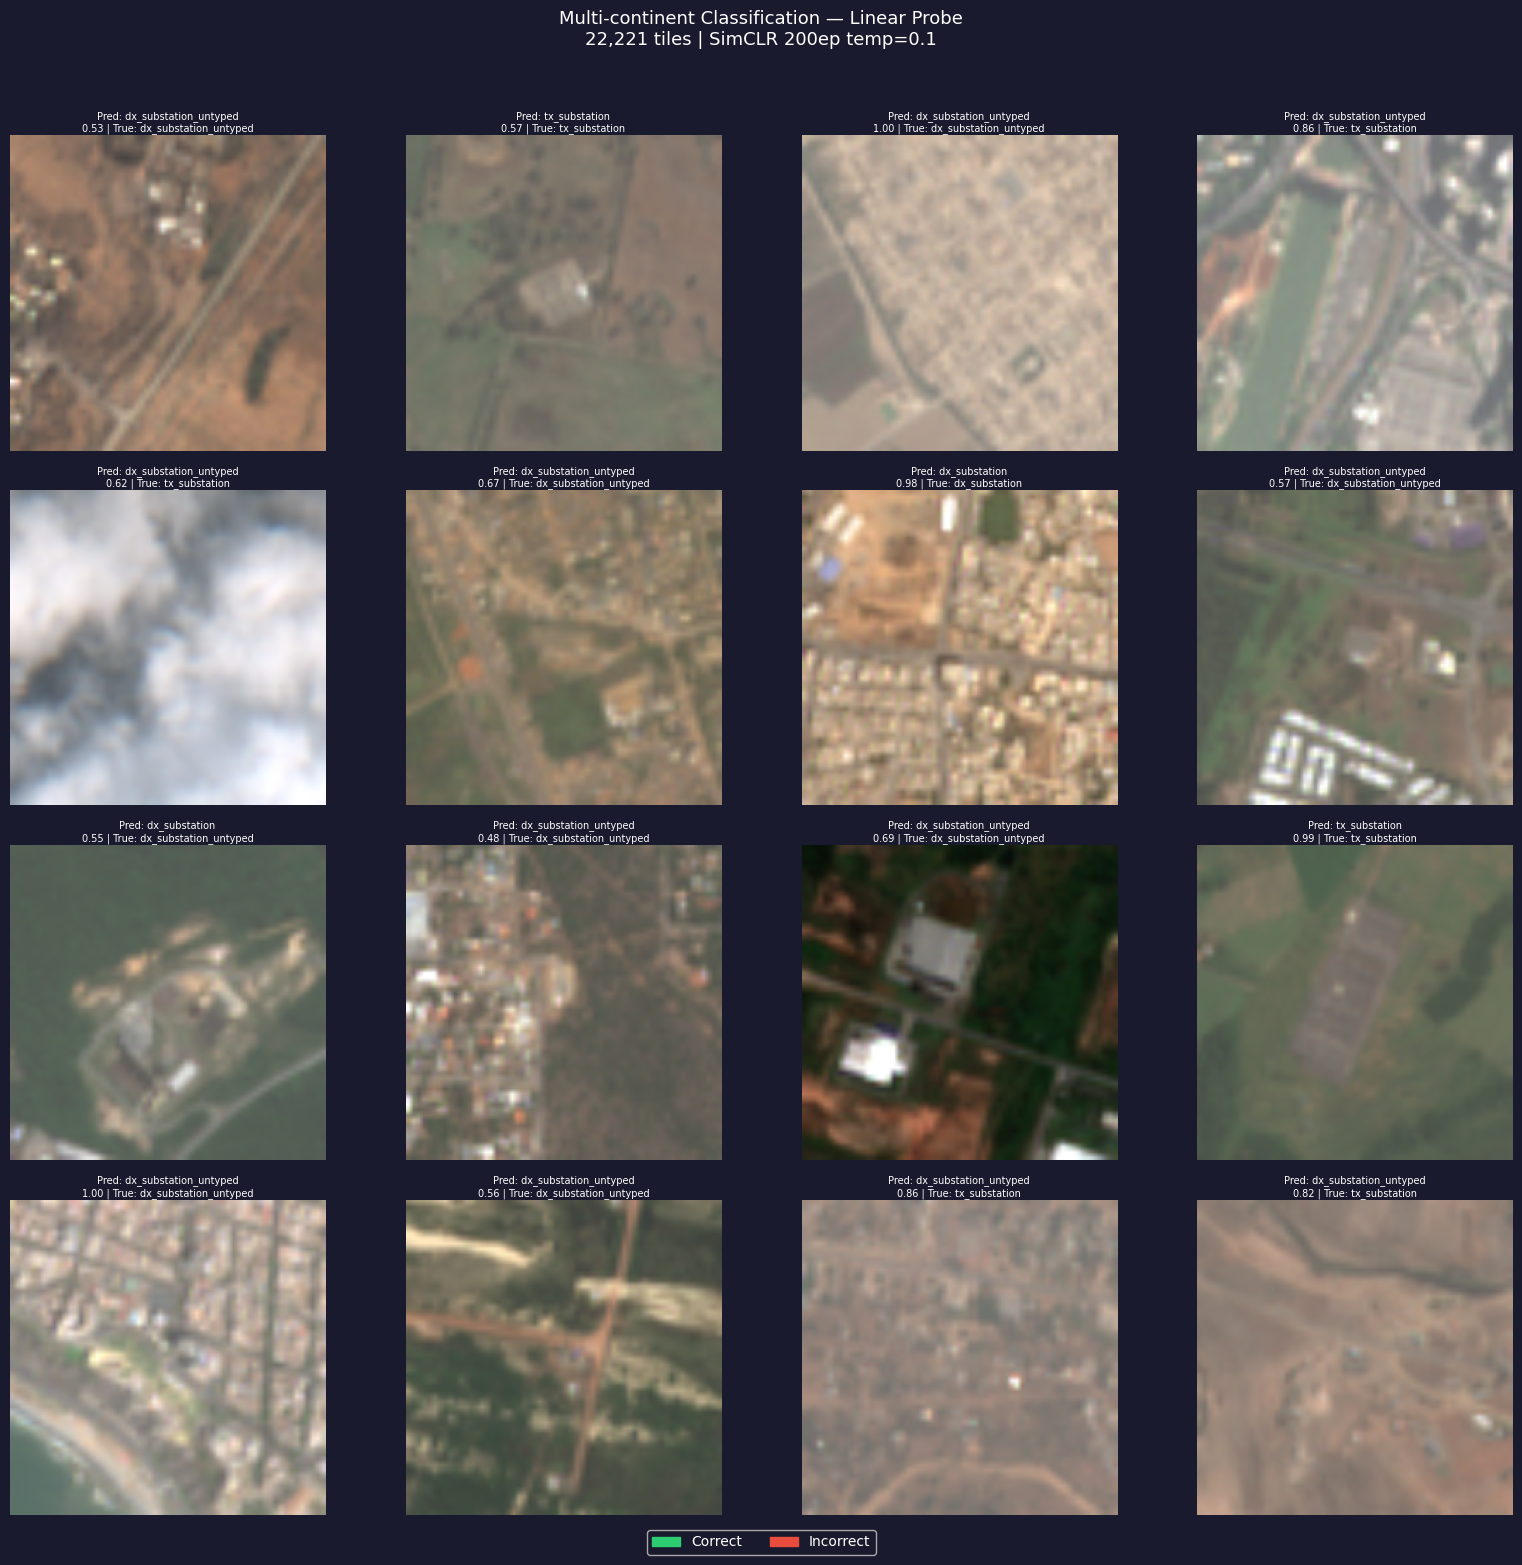

Saved to /content/drive/MyDrive/infra_fm/results/classification_multicontinent/prediction_grid.png


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch.nn.functional as F

# Load best model (linear probe)
ckpt_path = f'{RESULTS_DIR}/linear_probe/checkpoint_best.pt'
ckpt      = torch.load(ckpt_path, map_location='cpu')
in_channels = len(BAND_INDICES.split(','))

vis_model = SimCLRModel(
    backbone_name='resnet18', projection_dim=128,
    pretrained_backbone=False, in_channels=in_channels,
)
pretrain_ckpt = torch.load(CHECKPOINT, map_location='cpu')
vis_model.load_state_dict(pretrain_ckpt['model_state_dict'], strict=False)
vis_encoder = vis_model.backbone
vis_encoder.feature_dim = vis_model.feature_dim
vis_head = LinearClassifier(vis_encoder.feature_dim, len(unified_classes))
vis_head.load_state_dict(ckpt['head_state'])
vis_encoder.eval(); vis_head.eval()

# Sample validation tiles
device = torch.device('cpu')
train_idxs, val_idxs = split_indices(len(combined), TRAIN_FRACTION, SEED)
sample_idxs = random.sample(val_idxs, min(16, len(val_idxs)))

# Class colors
class_colors = {
    'energy.transmission.substation':         '#e74c3c',
    'energy.distribution.substation':         '#3498db',
    'energy.distribution.substation_untyped': '#2ecc71',
}
default_color = '#95a5a6'

fig, axes = plt.subplots(4, 4, figsize=(16, 16), facecolor='#1a1a2e')
fig.suptitle(
    f'Multi-continent Classification — Linear Probe\n'
    f'{len(combined):,} tiles | SimCLR 200ep temp=0.1',
    color='white', fontsize=13, y=0.98
)

for ax, idx in zip(axes.flat, sample_idxs):
    item  = combined[idx]
    image = item['image']   # (C, H, W) tensor
    true_label = unified_classes[item['label'].item()]

    # Get prediction
    with torch.no_grad():
        logits = vis_head(vis_encoder(image.unsqueeze(0)))
        probs  = F.softmax(logits, dim=1)[0]
        pred_idx  = probs.argmax().item()
        confidence = probs[pred_idx].item()
        pred_label = unified_classes[pred_idx]

    # Display RGB (bands 0,1,2)
    rgb = image[:3].permute(1, 2, 0).numpy()
    rgb = np.clip(rgb, 0, 1)
    ax.imshow(rgb)
    ax.axis('off')

    # Overlay prediction box
    is_correct = (pred_label == true_label)
    box_color  = class_colors.get(pred_label, default_color)
    border_color = '#2ecc71' if is_correct else '#e74c3c'

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(border_color)
        spine.set_linewidth(3)

    short_pred = short_class(pred_label)
    short_true = short_class(true_label)
    title = f'Pred: {short_pred}\n{confidence:.2f} | True: {short_true}'
    ax.set_title(title, color='white', fontsize=7, pad=3)

# Legend
legend_patches = [
    mpatches.Patch(color='#2ecc71', label='Correct'),
    mpatches.Patch(color='#e74c3c', label='Incorrect'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=2,
           facecolor='#1a1a2e', labelcolor='white', fontsize=10,
           bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
save_path = f'{RESULTS_DIR}/prediction_grid.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print(f'Saved to {save_path}')